# Experiment 1 — Stagnation Detection and IPOP Restarts

**Goal**: exploit the front-loading finding from Stage 1.  
Almost all L2 improvement happens in the first 10–20 generations (~100–200 queries).  
The remaining budget adds almost nothing. Two strategies to reallocate it:

1. **Stagnation restart** — detect plateau (no improvement for `T` consecutive  
   generations), then rerun Phase 1+2+3 with a different corruption family member,  
   spending the saved queries on a fresh start from a different boundary point.

2. **IPOP** — when sep-CMA-ES stagnates (σ collapses or no improvement for `T` gens),  
   restart with doubled population size `λ`. Larger `λ` gives better gradient estimates  
   after the easy gains are exhausted.

**Varying**: stagnation threshold `T ∈ {10, 15, 20}` and strategy {no-restart, stagnation-restart, IPOP}.  
**Budget**: 1000 Phase-3 queries shared across all restarts.  
**Dataset**: 30-image quick set (both models).

In [1]:
import os
import sys
from pathlib import Path

_candidates = [Path.cwd(), Path.cwd()/'STAGE_2', Path.cwd()/'Adversial ML'/'STAGE_2']
for _p in _candidates:
    if (_p / 'utils_stage2.py').exists():
        sys.path.insert(0, str(_p.resolve())); break
else:
    raise FileNotFoundError('utils_stage2.py not found')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs

from utils_stage2 import (
    clip01, compute_ssim, compute_l2, compute_linf,
    Oracle, load_models, get_jointly_correct,
    phase1, phase2, build_subspace_with_dc, sep_cmaes,
    lam_default, SSIM_STOP,
    H, W, C, N_QUICK, RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
os.makedirs('outputs/exp1', exist_ok=True)

Device: cpu


In [2]:
model_std, model_rob = load_models(device)
images = get_jointly_correct(model_std, model_rob, device, n=N_QUICK)
print(f'Images loaded: {len(images)}')

B = build_subspace_with_dc(k_dct=20, k_sp=20)   # DC-inclusive basis
print(f'Subspace shape: {B.shape}   (k={B.shape[0]}, n={B.shape[1]})')

Images loaded: 30
Subspace shape: (40, 3072)   (k=40, n=3072)


## Strategy A — Baseline (no restart)
Run sep-CMA-ES for the full 1000-query budget without any restart.

In [3]:
P3_BUDGET = 1000
LAM_BASE  = 10

def run_baseline(model, img_hwc, label, B, seed=0):
    oracle = Oracle(model, label, device)
    x_bnd, winner = phase1(oracle, img_hwc, seed=seed)
    if x_bnd is None:
        return None
    x_bnd = phase2(oracle, img_hwc, x_bnd)
    l2_p2 = compute_l2(img_hwc, x_bnd)
    best_x, best_l2, best_ssim, q3, hist = sep_cmaes(
        oracle, img_hwc, x_bnd, B,
        lam=LAM_BASE, max_queries=P3_BUDGET)
    return dict(l2_p2=l2_p2, l2_p3=best_l2, ssim_p3=best_ssim,
                improvement=l2_p2-best_l2, q_p3=q3,
                q_total=oracle.total, history=hist, winner=winner)

## Strategy B — Stagnation-triggered restart
Detect plateau (no L2 improvement for `T` consecutive generations), then:
1. Stop Phase 3 early, saving the remaining queries.
2. Re-run Phase 1 with the *second-best* family member (excluding the first winner).
3. Run Phase 2 on the new boundary point.
4. Run Phase 3 on the remaining budget.

If Phase 3 on the second start produces a better L2, keep it; otherwise keep the first.

In [4]:
def run_stagnation_restart(model, img_hwc, label, B, stag_T=15, seed=0):
    oracle = Oracle(model, label, device)

    # --- First pass ---
    x_bnd, winner1 = phase1(oracle, img_hwc, seed=seed)
    if x_bnd is None:
        return None
    x_bnd = phase2(oracle, img_hwc, x_bnd)
    l2_p2_1 = compute_l2(img_hwc, x_bnd)

    budget_first = P3_BUDGET // 2    # first run uses at most half
    best_x, best_l2, best_ssim, q3_1, hist1, stagnated = sep_cmaes(
        oracle, img_hwc, x_bnd, B,
        lam=LAM_BASE, max_queries=budget_first, stag_T=stag_T)

    histories = [('run-1', hist1)]
    remaining = P3_BUDGET - q3_1

    if not stagnated or remaining < LAM_BASE:
        # used full budget or no room for restart
        return dict(l2_p2=l2_p2_1, l2_p3=best_l2, ssim_p3=best_ssim,
                    improvement=l2_p2_1-best_l2, q_p3=q3_1,
                    q_total=oracle.total, histories=histories,
                    restarts=0, winner=winner1)

    # --- Restart with a different family member ---
    x_bnd2, winner2 = phase1(oracle, img_hwc, seed=seed+100,
                              exclude={winner1})
    if x_bnd2 is None:
        # no alternative; continue with remaining budget on same start
        best_x2, best_l2_2, best_ssim_2, q3_2, hist2 = sep_cmaes(
            oracle, img_hwc, x_bnd, B,
            lam=LAM_BASE, max_queries=remaining)
        histories.append(('run-2-same', hist2))
    else:
        x_bnd2 = phase2(oracle, img_hwc, x_bnd2)
        l2_p2_2 = compute_l2(img_hwc, x_bnd2)
        best_x2, best_l2_2, best_ssim_2, q3_2, hist2 = sep_cmaes(
            oracle, img_hwc, x_bnd2, B,
            lam=LAM_BASE, max_queries=remaining)
        histories.append(('run-2', hist2))

    if best_l2_2 < best_l2:
        best_l2, best_ssim = best_l2_2, best_ssim_2

    return dict(l2_p2=l2_p2_1, l2_p3=best_l2, ssim_p3=best_ssim,
                improvement=l2_p2_1-best_l2,
                q_p3=q3_1+q3_2, q_total=oracle.total,
                histories=histories, restarts=1,
                winner=winner1, winner2=winner2)

## Strategy C — IPOP restarts
When stagnation is detected, restart the same Phase 3 with doubled `λ`.  
Mean is reset to the best point found so far; covariance reset to identity.  
Cap at `λ_max = k` (one sample per subspace dimension).

In [5]:
def run_ipop(model, img_hwc, label, B,
             lam_init=4, lam_max=None, stag_T=15, seed=0):
    k = B.shape[0]
    if lam_max is None:
        lam_max = k  # one sample per subspace dimension

    oracle = Oracle(model, label, device)
    x_bnd, winner = phase1(oracle, img_hwc, seed=seed)
    if x_bnd is None:
        return None
    x_bnd = phase2(oracle, img_hwc, x_bnd)
    l2_p2 = compute_l2(img_hwc, x_bnd)

    lam = lam_init
    queries_p3 = 0
    best_x    = x_bnd.copy()
    best_l2   = l2_p2
    best_ssim = compute_ssim(img_hwc, best_x)
    all_histories = []
    restart = 0
    x_restart = x_bnd

    while queries_p3 < P3_BUDGET:
        remaining = P3_BUDGET - queries_p3
        if remaining < lam:
            break

        bx, bl2, bssim, q, hist, stagnated = sep_cmaes(
            oracle, img_hwc, x_restart, B,
            lam=lam, max_queries=remaining, stag_T=stag_T)

        queries_p3 += q
        all_histories.append((f'restart={restart} λ={lam}', hist))

        if bl2 < best_l2:
            best_l2 = bl2
            best_x  = bx
            best_ssim = bssim

        if best_ssim >= SSIM_STOP:
            break

        if not stagnated:
            break  # used full remaining budget

        # IPOP: double lambda, reset mean to best found
        lam = min(lam_max, lam * 2)
        x_restart = best_x
        restart += 1

    return dict(l2_p2=l2_p2, l2_p3=best_l2, ssim_p3=best_ssim,
                improvement=l2_p2-best_l2, q_p3=queries_p3,
                q_total=oracle.total, histories=all_histories,
                restarts=restart, winner=winner)

## Run experiments — both models, three strategies, three T values

In [6]:
STAG_TS  = [10, 15, 20]
MODELS   = [('standard', model_std), ('robust', model_rob)]

results = {}   # key: (model_name, strategy, T) -> list of result dicts

for model_name, model in MODELS:
    print(f'\n=== {model_name.upper()} ===')

    # Baseline (no restart, T irrelevant)
    key = (model_name, 'baseline', None)
    results[key] = []
    for rec in images:
        r = run_baseline(model, rec['img'], rec['label'], B, seed=rec['idx'])
        results[key].append(r)
    valid = [r for r in results[key] if r]
    print(f'  baseline  : median L2 = {np.median([r["l2_p3"] for r in valid]):.4f}')

    for T in STAG_TS:
        # Strategy B: stagnation restart
        key_sr = (model_name, 'stag_restart', T)
        results[key_sr] = []
        for rec in images:
            r = run_stagnation_restart(model, rec['img'], rec['label'], B,
                                       stag_T=T, seed=rec['idx'])
            results[key_sr].append(r)
        valid_sr = [r for r in results[key_sr] if r]
        print(f'  stag T={T}: median L2 = {np.median([r["l2_p3"] for r in valid_sr]):.4f}')

        # Strategy C: IPOP
        key_ip = (model_name, 'ipop', T)
        results[key_ip] = []
        for rec in images:
            r = run_ipop(model, rec['img'], rec['label'], B,
                         lam_init=4, stag_T=T, seed=rec['idx'])
            results[key_ip].append(r)
        valid_ip = [r for r in results[key_ip] if r]
        print(f'  IPOP T={T}: median L2 = {np.median([r["l2_p3"] for r in valid_ip]):.4f}')


=== STANDARD ===
  baseline  : median L2 = 2.8564
  stag T=10: median L2 = 3.4004
  IPOP T=10: median L2 = 2.2998
  stag T=15: median L2 = 2.8518
  IPOP T=15: median L2 = 2.2928
  stag T=20: median L2 = 3.4237
  IPOP T=20: median L2 = 2.6754

=== ROBUST ===
  baseline  : median L2 = 4.2078
  stag T=10: median L2 = 4.7505
  IPOP T=10: median L2 = 3.2988
  stag T=15: median L2 = 4.4913
  IPOP T=15: median L2 = 3.4979
  stag T=20: median L2 = 4.6146
  IPOP T=20: median L2 = 3.8994


## Results: L2 improvement distributions

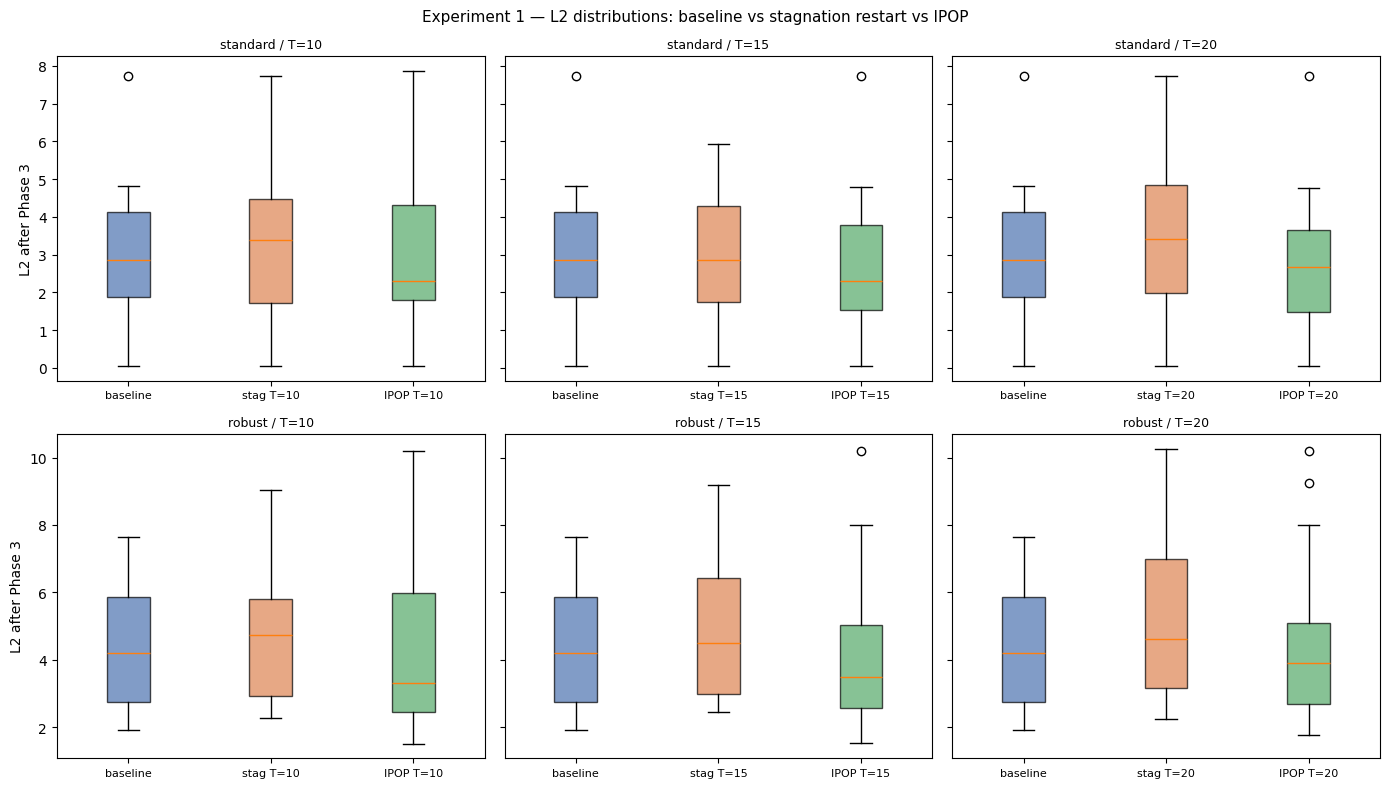

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row')

for row, (model_name, _) in enumerate(MODELS):
    # Collect L2 values per T for each strategy
    baseline_l2 = [r['l2_p3'] for r in results[(model_name,'baseline',None)] if r]

    for col, T in enumerate(STAG_TS):
        ax = axes[row][col]
        sr_l2 = [r['l2_p3'] for r in results[(model_name,'stag_restart',T)] if r]
        ip_l2 = [r['l2_p3'] for r in results[(model_name,'ipop',T)] if r]

        data   = [baseline_l2, sr_l2, ip_l2]
        labels = ['baseline', f'stag T={T}', f'IPOP T={T}']
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = ['#4C72B0', '#DD8452', '#55A868']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(f'{model_name} / T={T}', fontsize=9)
        if col == 0:
            ax.set_ylabel('L2 after Phase 3')

plt.suptitle('Experiment 1 — L2 distributions: baseline vs stagnation restart vs IPOP',
             fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp1/l2_distributions.png', dpi=150)
plt.show()

## Results: fraction of images where restart actually helped

In [8]:
print(f'{'Method':<30} {'model':<10} {'T':<5} {'helped%':>8} {'med L2':>10} {'med q_p3':>10}')
print('-' * 70)

baseline_l2s = {}
for model_name, _ in MODELS:
    baseline_l2s[model_name] = {
        i: r['l2_p3']
        for i, r in enumerate(results[(model_name,'baseline',None)])
        if r is not None
    }

for model_name, _ in MODELS:
    bl2 = baseline_l2s[model_name]
    for T in STAG_TS:
        for strategy in ['stag_restart', 'ipop']:
            recs = results[(model_name, strategy, T)]
            helped = sum(
                1 for i, r in enumerate(recs)
                if r and i in bl2 and r['l2_p3'] < bl2[i]
            )
            total  = sum(1 for r in recs if r)
            pct    = 100 * helped / total if total else 0
            l2s    = [r['l2_p3'] for r in recs if r]
            q3s    = [r['q_p3']  for r in recs if r]
            print(f'{strategy:<30} {model_name:<10} {T:<5} '
                  f'{pct:>7.1f}% {np.median(l2s):>10.4f} {np.median(q3s):>10.0f}')

Method                         model      T      helped%     med L2   med q_p3
----------------------------------------------------------------------
stag_restart                   standard   10       25.0%     3.4004        165
ipop                           standard   10       29.2%     2.2998        466
stag_restart                   standard   15       37.5%     2.8518        340
ipop                           standard   15       62.5%     2.2928        420
stag_restart                   standard   20       29.2%     3.4237        175
ipop                           standard   20       54.2%     2.6754        400
stag_restart                   robust     10       28.0%     4.7505        500
ipop                           robust     10       52.0%     3.2988       1000
stag_restart                   robust     15       16.0%     4.4913        500
ipop                           robust     15       56.0%     3.4979       1000
stag_restart                   robust     20       16.0%    

## IPOP restart count distribution

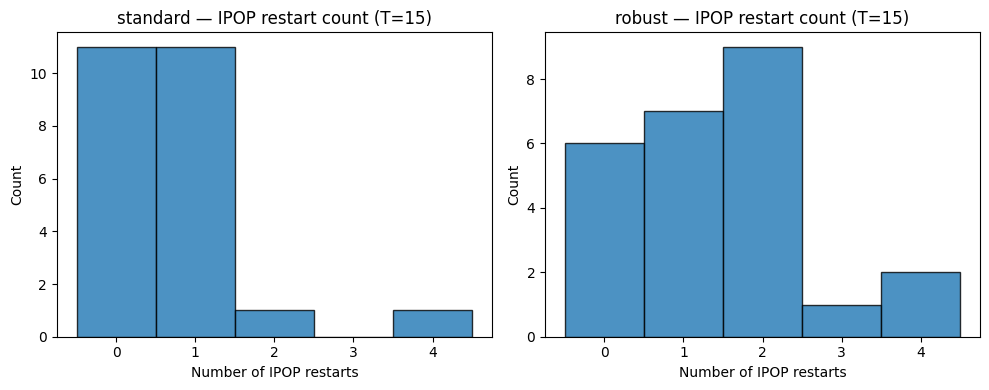

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (model_name, _) in zip(axes, MODELS):
    # Use T=15 for the IPOP restart count plot
    recs = [r for r in results[(model_name, 'ipop', 15)] if r]
    restarts = [r['restarts'] for r in recs]
    ax.hist(restarts, bins=range(max(restarts)+2), align='left', edgecolor='k', alpha=0.8)
    ax.set_xlabel('Number of IPOP restarts')
    ax.set_ylabel('Count')
    ax.set_title(f'{model_name} — IPOP restart count (T=15)')
plt.tight_layout()
plt.savefig('outputs/exp1/ipop_restart_counts.png', dpi=150)
plt.show()

## L2 curves: how improvement unfolds across restarts

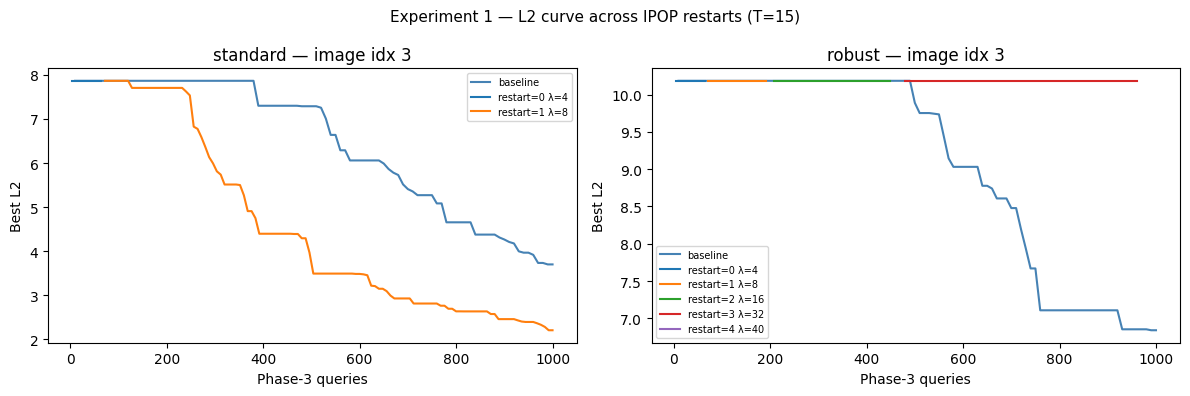

Experiment 1 complete. Outputs saved to outputs/exp1/


In [10]:
# Pick one representative image per model and show detailed L2 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (model_name, model) in zip(axes, MODELS):
    # Find an image where IPOP did multiple restarts
    recs_ipop = results[(model_name, 'ipop', 15)]
    idx_multi = next(
        (i for i, r in enumerate(recs_ipop) if r and r['restarts'] > 0), 0
    )
    rec_ip = recs_ipop[idx_multi]
    rec_bl = results[(model_name, 'baseline', None)][idx_multi]

    if rec_bl:
        qs_bl  = [h['queries'] for h in rec_bl['history']]
        l2_bl  = [h['best_l2'] for h in rec_bl['history']]
        ax.plot(qs_bl, l2_bl, label='baseline', color='steelblue')

    if rec_ip:
        offset = 0
        for label, hist in rec_ip['histories']:
            qs = [offset + h['queries'] for h in hist]
            l2 = [h['best_l2'] for h in hist]
            ax.plot(qs, l2, label=label)
            if qs:
                offset = qs[-1]

    ax.set_xlabel('Phase-3 queries')
    ax.set_ylabel('Best L2')
    ax.set_title(f'{model_name} — image idx {idx_multi}')
    ax.legend(fontsize=7)

plt.suptitle('Experiment 1 — L2 curve across IPOP restarts (T=15)', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp1/l2_curves_ipop_detail.png', dpi=150)
plt.show()
print('Experiment 1 complete. Outputs saved to outputs/exp1/')